# This is for looking at different classifiers on the profile data

## looking at the performance of different classification algorithms

### pull out the data for the 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# data preparation
#original data
df = pd.read_csv('datasets/ip_entropies_with_kmeans.csv')
# drop unnecessary columns
df = df.drop(columns=['src_ip'])

df_normalized = df[['total_sessions', 'username_entropy', 'password_entropy', 'command_entropy']]
df_normalized = df_normalized.fillna(0)
scaler = MinMaxScaler()
normalized_values = scaler.fit_transform(df_normalized)
normalized_data = pd.DataFrame(normalized_values, columns=df_normalized.columns)
# add labels to normalized data
normalized_data['cluster'] = df['kmeans_cluster']

X = normalized_data[['total_sessions', 'username_entropy', 'password_entropy', 'command_entropy']]
y = normalized_data[['cluster']]

# split the training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### logistic regression

/home/savage/Cowrie-Behavioral-Analyasis/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/savage/Cowrie-Behavioral-Analyasis/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       406
           2       0.98      1.00      0.99       536
           3       1.00      0.55      0.71        29
           4       1.00      1.00      1.00        45

    accuracy                           0.99      1016
   macro avg       0.99      0.89      0.92      1016
weighted avg       0.99      0.99      0.99      1016

[[406   0   0   0]
 [  0 536   0   0]
 [  1  12  16   0]
 [  0   0   0  45]]


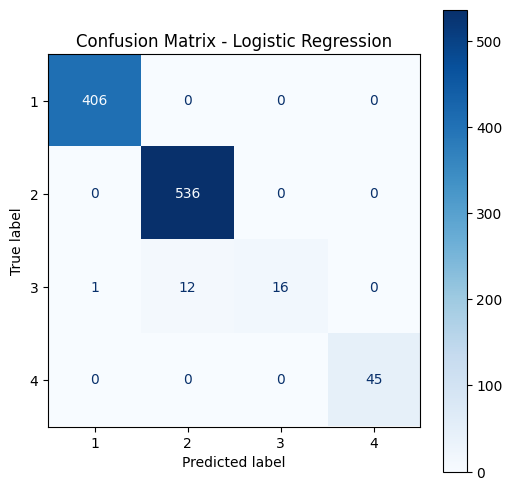

In [3]:
from sklearn.linear_model import LogisticRegression

# Family: Linear Model
logreg = LogisticRegression(
    multi_class='multinomial',  # better for >2 classes
    solver='lbfgs',
    max_iter=1000,
    n_jobs=-1
)

logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))

cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Decision tree

=== Decision Tree ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       406
           2       1.00      1.00      1.00       536
           3       0.90      0.97      0.93        29
           4       1.00      0.93      0.97        45

    accuracy                           1.00      1016
   macro avg       0.97      0.97      0.97      1016
weighted avg       1.00      1.00      1.00      1016

[[406   0   0   0]
 [  0 535   1   0]
 [  0   1  28   0]
 [  0   1   2  42]]


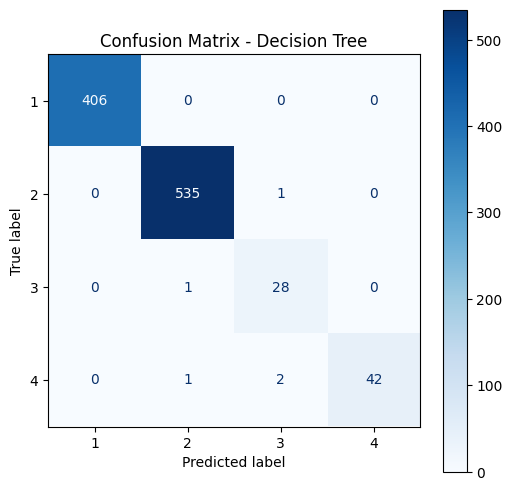

In [4]:
from sklearn.tree import DecisionTreeClassifier

# Family: Non-Linear Tree
dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,        # or set like 3–10 to reduce overfitting
    min_samples_split=2,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### random forest

/home/savage/Cowrie-Behavioral-Analyasis/venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


=== Random Forest ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       406
           2       1.00      1.00      1.00       536
           3       0.97      0.97      0.97        29
           4       1.00      0.98      0.99        45

    accuracy                           1.00      1016
   macro avg       0.99      0.99      0.99      1016
weighted avg       1.00      1.00      1.00      1016

[[406   0   0   0]
 [  0 535   1   0]
 [  0   1  28   0]
 [  0   1   0  44]]


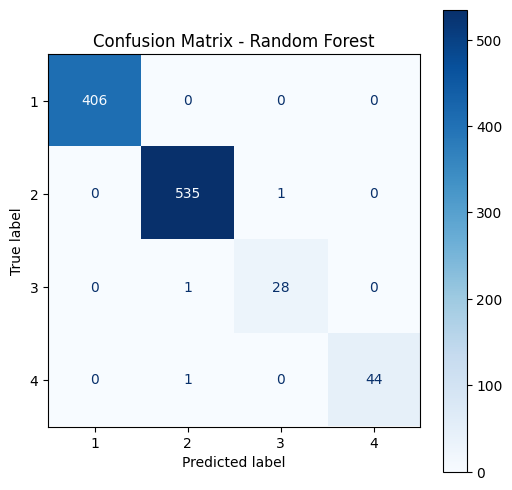

In [5]:
from sklearn.ensemble import RandomForestClassifier

# Family: Non-Linear Ensemble
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

### KNN

=== k-NN ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       406
           2       1.00      1.00      1.00       536
           3       1.00      0.97      0.98        29
           4       1.00      1.00      1.00        45

    accuracy                           1.00      1016
   macro avg       1.00      0.99      1.00      1016
weighted avg       1.00      1.00      1.00      1016

[[406   0   0   0]
 [  0 536   0   0]
 [  0   1  28   0]
 [  0   0   0  45]]


/home/savage/Cowrie-Behavioral-Analyasis/venv/lib/python3.10/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


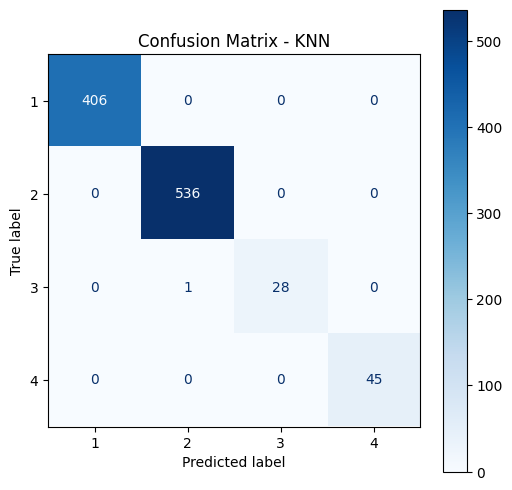

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Family: Instance-Based
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',   # or 'uniform'
        metric='minkowski',   # Euclidean by default
        n_jobs=-1
    ))
])

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("=== k-NN ===")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - KNN")
plt.show()

### SVM

/home/savage/Cowrie-Behavioral-Analyasis/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== SVM (RBF) ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       406
           2       0.99      1.00      0.99       536
           3       1.00      0.79      0.88        29
           4       1.00      1.00      1.00        45

    accuracy                           0.99      1016
   macro avg       1.00      0.95      0.97      1016
weighted avg       0.99      0.99      0.99      1016

[[406   0   0   0]
 [  0 536   0   0]
 [  0   6  23   0]
 [  0   0   0  45]]


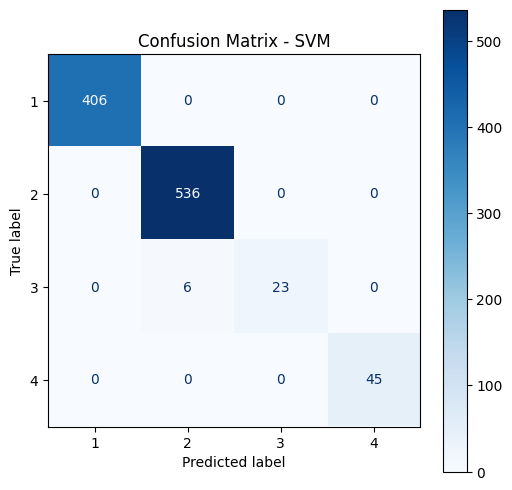

In [7]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Family: Non-Linear Kernel
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=False,    # True if you want predict_proba (slower)
        random_state=42
    ))
])

svm_rbf.fit(X_train, y_train)
y_pred_svm = svm_rbf.predict(X_test)

print("=== SVM (RBF) ===")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - SVM")
plt.show()


### Multi-layered perception MLP

#### sci-kit learn

/home/savage/Cowrie-Behavioral-Analyasis/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== MLP (64, 32, 16) - sklearn ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       406
           2       1.00      1.00      1.00       536
           3       1.00      0.97      0.98        29
           4       0.98      1.00      0.99        45

    accuracy                           1.00      1016
   macro avg       0.99      0.99      0.99      1016
weighted avg       1.00      1.00      1.00      1016

[[406   0   0   0]
 [  0 536   0   0]
 [  0   0  28   1]
 [  0   0   0  45]]


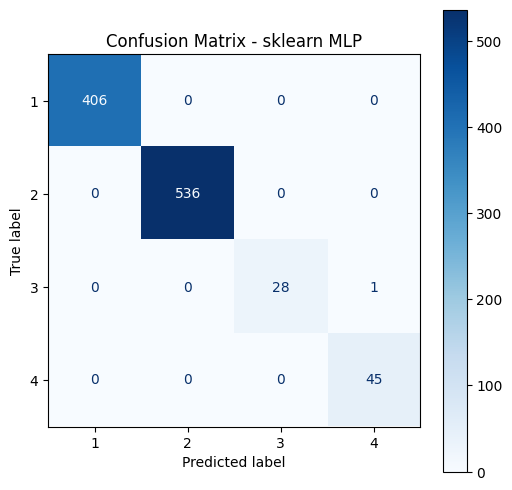

In [8]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),  # ← 3 hidden layers now
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

print("=== MLP (64, 32, 16) - sklearn ===")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - sklearn MLP")
plt.show()

#### pytorch

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# X (normalized), y (labels in {1,2,3,4})
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# convert labels to 0-based for CrossEntropyLoss
y_train_0 = y_train - 1
y_test_0  = y_test - 1

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_0, dtype=torch.long)
y_test_t  = torch.tensor(y_test_0,  dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

input_dim = X_train_t.shape[1]    # should be 4
num_classes = len(np.unique(y))   # 4

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(input_dim, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    print(f"Epoch {epoch+1:02d}/{num_epochs} - Loss: {epoch_loss:.4f}")

# eval
model.eval()
with torch.no_grad():
    logits_test = model(X_test_t.to(device))
    preds_0 = torch.argmax(logits_test, dim=1).cpu().numpy()

y_pred = preds_0 + 1  # back to {1,2,3,4}

print("=== MLP (64, 32, 16) - PyTorch ===")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1,2,3,4])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Confusion Matrix - PyTorch MLP")
plt.show()   

ValueError: could not determine the shape of object type 'DataFrame'